In [32]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import geopandas as gpd
import regionmask
import zipfile
import tempfile
import rioxarray

In [33]:
# Configuration
VAULT_DIR = "/data0/skagit_met/data_transfer/data"
BASE_DIR = "/data0/hernanqd/plots_code/skagit_basin_de"
HUC8_GEO = os.path.join(BASE_DIR, "data/GIS/SkagitSubBasin_HUC8.geojson")
EVENTS_CSV = os.path.join(BASE_DIR, "multi_product_bulk_bias/outputs/4_clean_bias_table.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "cumulative_precipitation_plot")

# Hydrology data paths
HYDRO_BASE_DIR = "/data0/nksp2/skagit/skagit_2/skagit-met"
HYDRO_EXP_DATA_DIR = os.path.join(HYDRO_BASE_DIR, "experiments_2/data")
HYDRO_Q_PATH = os.path.join(HYDRO_EXP_DATA_DIR, "usgs_12200500_discharge.rdb")

In [34]:
# Specific event dates to plot
# Can be a string date or a dict with 'event_date', 'start_date', 'end_date' for custom ranges
SPECIFIC_DATES = [
    # '2003-10-29',
    # '2006-11-04',
    # '2021-11-15',
    # '1990-11-25',
    # '2017-11-23',
    # '2010-12-13',
    '1990-11-25',
    '2010-12-13',
    '1984-01-05',
    '2017-11-23',
    '1999-11-13',
    '2011-01-17',
    {'event_date': '2003-10-29', 'start_date': '2003-10-14', 'end_date': '2003-11-03'},  # custom range
    '1995-11-26'
]

In [35]:
def load_prism_from_new_format(date, prism_root):
    """Load PRISM data from new format (TIFF) zip file for a specific date"""
    date_str = date.strftime('%Y%m%d')
    year = date.year
    decade_folder = get_decade_folder(year)
    zip_path = os.path.join(prism_root, decade_folder, f"prism_ppt_us_25m_{date_str}.zip")

    if not os.path.exists(zip_path):
        return None

    try:
        with tempfile.TemporaryDirectory() as tmpdir:
            with zipfile.ZipFile(zip_path, 'r') as z:
                z.extractall(tmpdir)
                for root, dirs, files in os.walk(tmpdir):
                    for f in files:
                        if f.endswith('.tif'):
                            filepath = os.path.join(root, f)
                            da = rioxarray.open_rasterio(filepath)
                            return da.squeeze().copy(deep=True)
    except Exception as e:
        print(f"  Error loading PRISM (new format) for {date_str}: {e}")

    return None


def load_prism_from_zip(date, vault_dir):
    """Load PRISM data from zip file for a specific date"""
    date_str = date.strftime('%Y%m%d')
    year = date.year
    decade_folder = get_decade_folder(year)
    zip_path = os.path.join(vault_dir, "PRISM", decade_folder, f"ppt_{date_str}_4km.zip")

    if not os.path.exists(zip_path):
        return None

    try:
        with tempfile.TemporaryDirectory() as tmpdir:
            with zipfile.ZipFile(zip_path, 'r') as z:
                z.extractall(tmpdir)
                # Find NetCDF file
                for root, dirs, files in os.walk(tmpdir):
                    for f in files:
                        if f.endswith('.nc'):
                            filepath = os.path.join(root, f)
                            ds = xr.open_dataset(filepath)
                            # Make a deep copy so it persists after tmpdir is deleted
                            return ds.copy(deep=True)
    except Exception as e:
        print(f"  Error loading PRISM from zip for {date_str}: {e}")

    return None


def load_usgs_rdb(filepath, param_name):
    """Load USGS RDB file"""
    try:
        df = pd.read_csv(filepath, sep='\t', comment='#')
        df = df.iloc[1:].reset_index(drop=True)
        val_cols = [c for c in df.columns if '_00' in c and not c.endswith('_cd')]
        if not val_cols: return pd.DataFrame(columns=['date', param_name])
        val_col = val_cols[0]
        df = df[['datetime', val_col]]
        df.columns = ['date', param_name]
        df['date'] = pd.to_datetime(df['date'])
        df[param_name] = pd.to_numeric(df[param_name], errors='coerce')
        return df
    except Exception as e:
        print(f"  Error loading {filepath}: {e}")
        return pd.DataFrame(columns=['date', param_name])


def load_regions():
    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    return gdf


def get_mask(gdf, lon, lat):
    mask = regionmask.mask_3D_geopandas(gdf, lon, lat)
    region_indices = []
    for r in ["Upper Skagit", "Sauk", "Lower Skagit"]:
        idx = gdf[gdf["Name"].str.contains(r, case=False)].index[0]
        region_indices.append(idx)
    return mask.sel(region=region_indices)


def calculate_basin_mean(da, mask_2d):
    data = da.values
    mask = mask_2d.values if hasattr(mask_2d, 'values') else mask_2d

    if data.ndim == 3:
        time_steps = data.shape[0]
        data_flat = data.reshape(time_steps, -1)
        mask_flat = mask.flatten()
        mask_idx = mask_flat > 0
        if mask_idx.any():
            mean_vals = np.nanmean(data_flat[:, mask_idx], axis=1)
        else:
            mean_vals = np.full(time_steps, np.nan)
        time_coord = da.time.values if 'time' in da.coords else range(time_steps)
        return pd.Series(mean_vals, index=pd.to_datetime(time_coord))
    elif data.ndim == 2:
        # Mask out nodata values (typically -9999 or negative values for TIFF)
        data = data.astype(float)
        data[data < 0] = np.nan  # Treat negative values as nodata

        data_flat = data.flatten()
        mask_flat = mask.flatten()
        mask_idx = mask_flat > 0
        if mask_idx.any():
            mean_val = np.nanmean(data_flat[mask_idx])
        else:
            mean_val = np.nan
        return mean_val
    else:
        raise ValueError(f"Unexpected data dimensions: {data.ndim}")


def get_decade_folder(year: int) -> str:
    start_decade = (year // 10) * 10
    if start_decade == 1980 and year > 1980:
        return "1981-1990"
    if year % 10 == 0 and year > 1980:
        return f"{start_decade-9}-{start_decade}"
    if start_decade % 10 == 0:
        return f"{start_decade+1}-{start_decade+10}"
    return f"{start_decade}-{(year//10)*10+9}"


# def get_ornl_zarr(year):
#     if 1981 <= year <= 2011:
#         p = os.path.join(VAULT_DIR, "climate_sets/1981_2011_ORNL_data.zarr")
#         if os.path.exists(p):
#             return p
#     p1 = os.path.join(VAULT_DIR, f"ornl/{year}_{year}_ref_DaymetV4_ORNL_data.zarr")
#     if os.path.exists(p1):
#         return p1
#     p2 = os.path.join(VAULT_DIR, f"DaymetV4/{year}_{year}_ORNL_data.zarr")
#     if os.path.exists(p2):
#         return p2
#     return None

def load_daymet_from_netcdf(year):
    """Load Daymet data from netCDF file for a specific year"""
    daymet_nc_path = os.path.join(DAYMET_NC_DIR, f"prcp_{year}_subset.nc")
    
    if not os.path.exists(daymet_nc_path):
        return None
    
    try:
        ds = xr.open_dataset(daymet_nc_path)
        return ds
    except Exception as e:
        print(f"  Error loading Daymet netCDF for {year}: {e}")
        return None

In [ ]:
def extract_event_window(event_date, products_to_extract=['prism', 'pnnl', 'daymet', 'conus', 'ucla', 'gridmet'], start_date=None, end_date=None):
    """Extract precipitation window for an event. Default is 8-day window (T-2 to T+5), but can use custom range."""

    if start_date and end_date:
        # Custom date range
        start_dt = pd.Timestamp(start_date)
        end_dt = pd.Timestamp(end_date)
        window_dates = pd.date_range(start_dt, end_dt, freq='D').tolist()
    else:
        # Default 8-day window (T-2 to T+5)
        window_dates = []
        for i in range(-2, 6):
            window_dates.append(event_date + pd.Timedelta(days=i))

    year = event_date.year
    results = {f'{date.strftime("%Y-%m-%d")}': {} for date in window_dates}

    gdf = load_regions()
    masks_2d = {}

    try:
        sample_geo = xr.open_dataset(os.path.join(VAULT_DIR, "PNNL/SERDP6km.geo_em.d01.nc"))
        masks_2d['PNNL'] = get_mask(gdf, sample_geo.XLONG_M.values[0], sample_geo.XLAT_M.values[0]).any(dim='region')
    except:
        pass


    try:
        sample_conus = xr.open_zarr(os.path.join(BASE_DIR, "data/weather_data/conus404_skagit_precip_daily_full.zarr"))
        masks_2d['CONUS404'] = get_mask(gdf, sample_conus.lon, sample_conus.lat).any(dim='region')
        sample_conus.close()
    except:
        pass

    try:
        ucla_static = xr.open_dataset(os.path.join(VAULT_DIR, "ucla_era5_d02_daily/static/wrfinput_d02_coord.nc"))
        masks_2d['UCLA'] = get_mask(gdf, ucla_static.lon2d.values, ucla_static.lat2d.values).any(dim='region')
    except:
        pass

    try:
        sample_gridmet = xr.open_zarr(os.path.join(VAULT_DIR, "gridmet/2021_daily_4km_gridMET_data.zarr"))
        masks_2d['GridMET'] = get_mask(gdf, sample_gridmet.lon, sample_gridmet.lat).any(dim='region')
    except:
        pass

    # # Extract PRISM from new format (TIFF) or fallback to old zip format
    if 'prism' in products_to_extract:
        prism_root = os.path.join(VAULT_DIR, "prism_new_hq")
        prism_data = {}

        for date in window_dates:
            da = load_prism_from_new_format(date, prism_root)
            if da is None:
                continue
            lon = da.x.values
            lat = da.y.values
            m_prism = get_mask(gdf, lon, lat).any(dim='region')
            mean_val = calculate_basin_mean(da, m_prism)
            prism_data[date.normalize()] = mean_val

        for date in window_dates:
            normalized_date = date.normalize()
            if normalized_date in prism_data:
                results[f'{date.strftime("%Y-%m-%d")}']['prism'] = float(prism_data[normalized_date])

        prism_count = sum(1 for v in prism_data.values() if not np.isnan(v))
        if prism_count > 0:
            print(f"  ✓ PRISM: {prism_count}/{len(window_dates)} dates extracted")

    # Extract PNNL
    if 'pnnl' in products_to_extract and year <= 2020:
        try:
            pnnl_path = os.path.join(VAULT_DIR, "PNNL/historical", str(year), f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc")
            if os.path.exists(pnnl_path):
                ds = xr.open_dataset(pnnl_path)
                hourly_dates = []
                for d in window_dates:
                    hourly_dates.extend(pd.date_range(d, d + pd.Timedelta(hours=23), freq='h'))
                available_hourly = [d for d in hourly_dates if d in ds.time.values]
                if available_hourly and 'PNNL' in masks_2d:
                    da_subset = ds['PREC_ACC_NC'].sel(time=available_hourly)
                    s_hourly = calculate_basin_mean(da_subset, masks_2d['PNNL'])
                    pnnl_daily = s_hourly.resample('1D').sum()
                    pnnl_daily.index = pnnl_daily.index.normalize()
                    for date in window_dates:
                        normalized_date = date.normalize()
                        if normalized_date in pnnl_daily.index:
                            val = pnnl_daily[normalized_date]
                            results[f'{date.strftime("%Y-%m-%d")}']['pnnl'] = float(val) if not isinstance(val, pd.Series) else float(val.iloc[0])
                ds.close()
        except Exception as e:
            print(f"Error loading PNNL for {event_date.strftime('%Y-%m-%d')}: {e}")

    # Extract Daymet
    if 'daymet' in products_to_extract:
        try:
            # Load dataset for the year
            ds = load_daymet_from_netcdf(year)
            
            if ds is not None:
                # Normalize time to midnight (your data has 12:00)
                ds['time'] = pd.to_datetime(ds.time.values).normalize()
                
                # Extract precipitation (time, y, x) = (365, 173, 165)
                da = ds['prcp']
                
                # Extract 2D coordinates
                lon_2d = ds['lon'].values  # (y, x) = (173, 165)
                lat_2d = ds['lat'].values  # (y, x) = (173, 165)
                
                # Create mask if not already cached
                if 'Daymet' not in masks_2d:
                    # regionmask.mask_3D_geopandas handles 2D coordinate arrays
                    masks_2d['Daymet'] = get_mask(gdf, lon_2d, lat_2d).any(dim='region')
                    print(f"  Created Daymet mask with shape {masks_2d['Daymet'].shape}")
                
                # Select dates in window
                da_window = da.sel(time=window_dates, method='nearest')
                print(f"  Selected {len(da_window.time)} dates for Daymet")
                
                # Calculate basin mean (handles 3D data)
                daymet_daily = calculate_basin_mean(da_window, masks_2d['Daymet'])
                daymet_daily.index = daymet_daily.index.normalize()
                daymet_daily = daymet_daily[~daymet_daily.index.duplicated(keep='first')]
                
                # Store results
                daymet_count = 0
                for date in window_dates:
                    normalized_date = date.normalize()
                    if normalized_date in daymet_daily.index:
                        val = daymet_daily[normalized_date]
                        results[f'{date.strftime("%Y-%m-%d")}']['daymet'] = float(val) if not isinstance(val, pd.Series) else float(val.iloc[0])
                        daymet_count += 1
                
                print(f"  ✓ Daymet: {daymet_count}/{len(window_dates)} dates extracted")
                
                ds.close()
                
        except Exception as e:
            print(f"Error loading Daymet for {event_date.strftime('%Y-%m-%d')}: {e}")
            import traceback
            traceback.print_exc()


    # Extract CONUS404
    if 'conus' in products_to_extract:
        try:
            conus_path = os.path.join(BASE_DIR, "data/weather_data/conus404_skagit_precip_daily_full.zarr")
            if os.path.exists(conus_path):
                ds = xr.open_zarr(conus_path)
                ds['time'] = pd.to_datetime(ds.time.values).normalize()
                da = ds['precip_daily'].sel(time=window_dates, method='nearest')
                if 'CONUS404' in masks_2d:
                    conus_daily = calculate_basin_mean(da, masks_2d['CONUS404'])
                    conus_daily.index = conus_daily.index.normalize()
                    conus_daily = conus_daily[~conus_daily.index.duplicated(keep='first')]
                    for date in window_dates:
                        normalized_date = date.normalize()
                        if normalized_date in conus_daily.index:
                            val = conus_daily[normalized_date]
                            results[f'{date.strftime("%Y-%m-%d")}']['conus'] = float(val) if not isinstance(val, pd.Series) else float(val.iloc[0])
                ds.close()
        except Exception as e:
            print(f"Error loading CONUS404 for {event_date.strftime('%Y-%m-%d')}: {e}")

    # Extract UCLA
    if 'ucla' in products_to_extract:
        try:
            u_paths = [
                os.path.join(VAULT_DIR, "ucla_era5_d02_daily", "prec", f"prec.daily.era5.d02.{year-1}.nc"),
                os.path.join(VAULT_DIR, "ucla_era5_d02_daily", "prec", f"prec.daily.era5.d02.{year}.nc")
            ]
            series_list = []
            for p in u_paths:
                if os.path.exists(p):
                    try:
                        ds = xr.open_dataset(p)
                        u_var = "prec" if "prec" in ds.data_vars else "pr"
                        if 'day' in ds.dims:
                            ds = ds.rename({'day': 'time'})
                        ds['time'] = pd.to_datetime(ds.time.values).normalize()
                        available_dates = [d for d in window_dates if d in ds.time.values]
                        if available_dates and 'UCLA' in masks_2d:
                            da_subset = ds[u_var].sel(time=available_dates)
                            s = calculate_basin_mean(da_subset, masks_2d['UCLA'])
                            s.index = s.index.normalize()
                            series_list.append(s)
                        ds.close()
                    except:
                        pass
            if series_list:
                ucla_daily = pd.concat(series_list).sort_index()
                ucla_daily = ucla_daily[~ucla_daily.index.duplicated(keep='first')]
                for date in window_dates:
                    normalized_date = date.normalize()
                    if normalized_date in ucla_daily.index:
                        val = ucla_daily[normalized_date]
                        results[f'{date.strftime("%Y-%m-%d")}']['ucla'] = float(val) if not isinstance(val, pd.Series) else float(val.iloc[0])
        except Exception as e:
            print(f"Error loading UCLA for {event_date.strftime('%Y-%m-%d')}: {e}")

    # Extract GridMET
    if 'gridmet' in products_to_extract:
        try:
            gridmet_path = os.path.join(VAULT_DIR, f"gridmet/{year}_daily_4km_gridMET_data.zarr")
            if os.path.exists(gridmet_path):
                ds = xr.open_zarr(gridmet_path)
                if 'day' in ds.dims:
                    ds = ds.rename({'day': 'time'})
                ds['time'] = pd.to_datetime(ds.time.values).normalize()
                var = 'prcp' if 'prcp' in ds.data_vars else 'precipitation_amount'
                da = ds[var].sel(time=window_dates, method='nearest')
                if 'GridMET' in masks_2d:
                    gridmet_daily = calculate_basin_mean(da, masks_2d['GridMET'])
                    gridmet_daily.index = gridmet_daily.index.normalize()
                    gridmet_daily = gridmet_daily[~gridmet_daily.index.duplicated(keep='first')]
                    for date in window_dates:
                        normalized_date = date.normalize()
                        if normalized_date in gridmet_daily.index:
                            val = gridmet_daily[normalized_date]
                            results[f'{date.strftime("%Y-%m-%d")}']['gridmet'] = float(val) if not isinstance(val, pd.Series) else float(val.iloc[0])
                ds.close()
        except Exception as e:
            print(f"Error loading GridMET for {event_date.strftime('%Y-%m-%d')}: {e}")

    return pd.DataFrame(results).T


Loading events data...
Loading discharge data...
Extracting and plotting 8 specific AR events...
Extracting data for 1990-11-25...
  ✓ PRISM: 8/8 dates extracted
  Created Daymet mask with shape (173, 165)
  Selected 8 dates for Daymet
  ✓ Daymet: 8/8 dates extracted
    PRISM data: [ 58.35394072 111.98357554  58.59955264   8.00107457  15.79645694
   5.21649905  18.2656692   22.1269197 ]
Extracting data for 2010-12-13...
  ✓ PRISM: 8/8 dates extracted
  Created Daymet mask with shape (173, 165)
  Selected 8 dates for Daymet
  ✓ Daymet: 8/8 dates extracted
    PRISM data: [10.78200764 49.37990836 81.95694262 16.90288337 16.91742254  5.95818356
  1.66877056  3.3866348 ]
Extracting data for 1984-01-05...
  ✓ PRISM: 8/8 dates extracted
  Created Daymet mask with shape (173, 165)
  Selected 8 dates for Daymet
  ✓ Daymet: 8/8 dates extracted
    PRISM data: [33.38994268 61.34257172 36.6623958  15.28110517  3.75278011  8.86114531
  2.59469216  5.79579349]
Extracting data for 2017-11-23...
  ✓

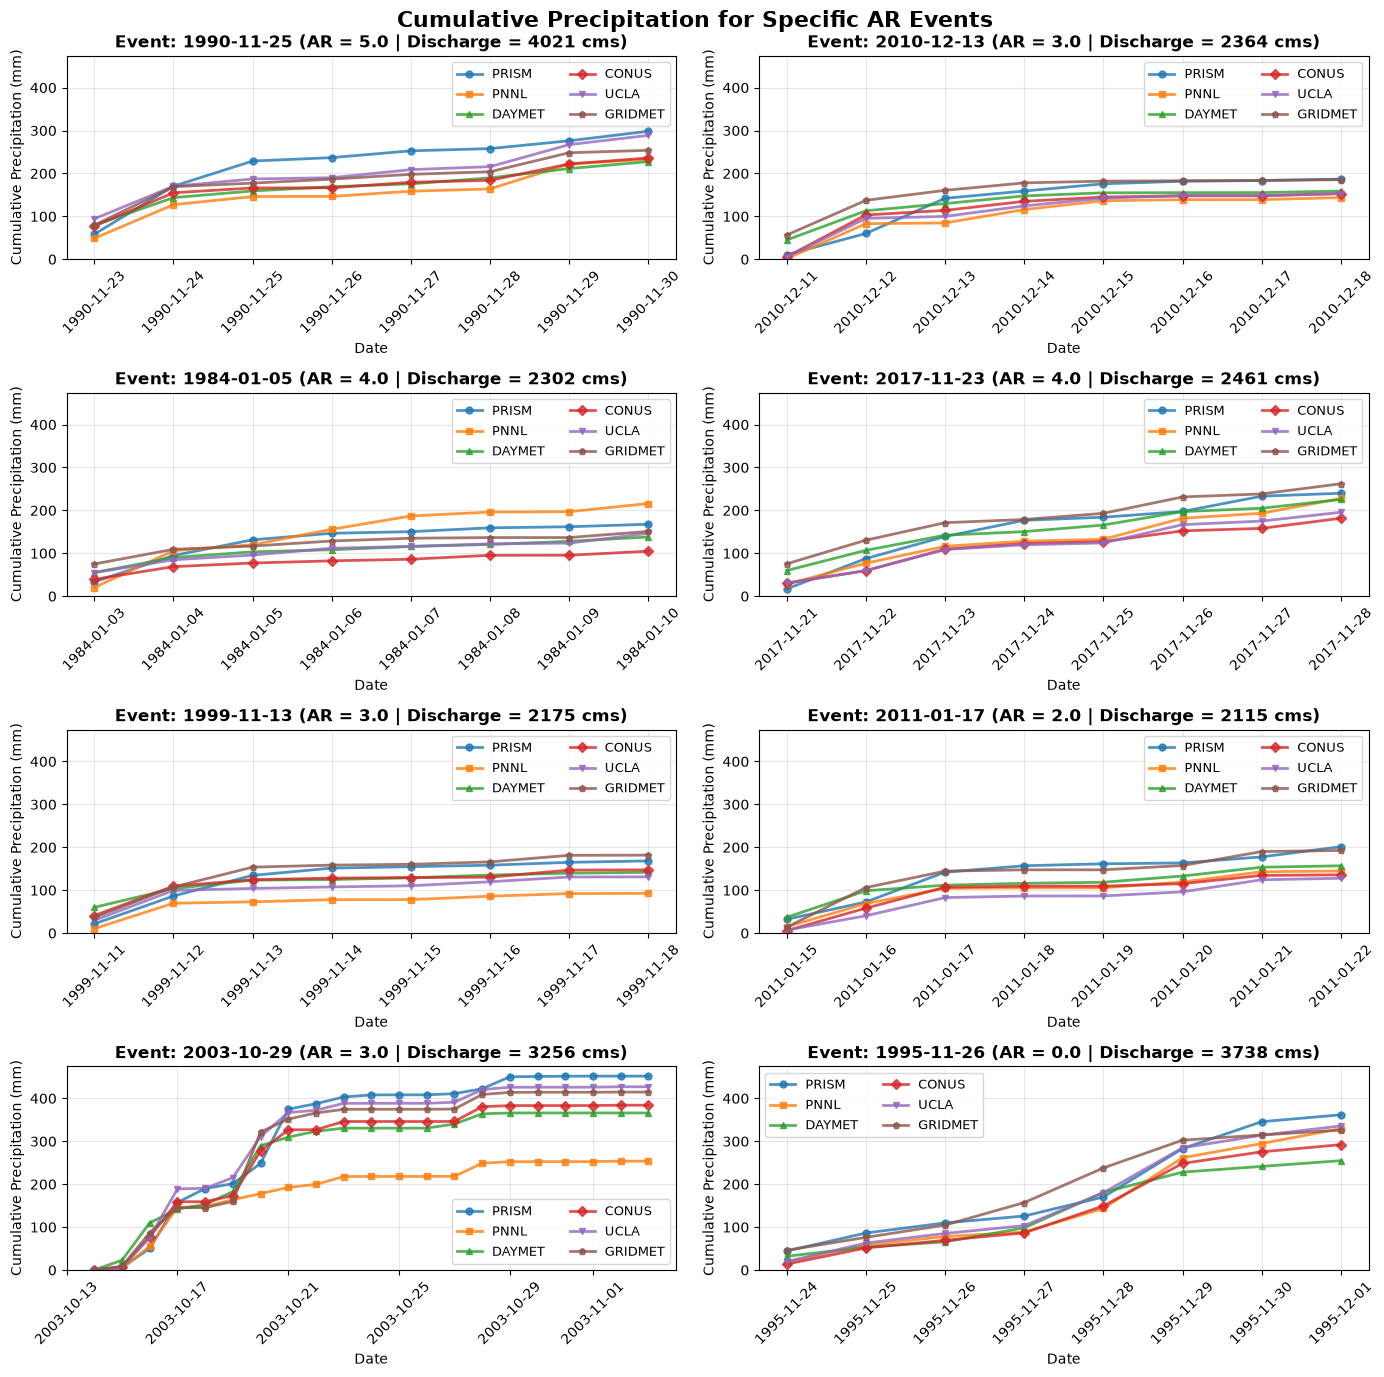

In [ ]:
"""Extract and plot specific AR events"""
print("Loading events data...") 
events_df = pd.read_csv(EVENTS_CSV)
events_df['date'] = pd.to_datetime(events_df['date'])

print("Loading discharge data...")
q_df = load_usgs_rdb(HYDRO_Q_PATH, 'discharge_cfs')

# Convert specific dates to datetime and extract date/range info
events_info = []
for d in SPECIFIC_DATES:
    if isinstance(d, dict):
        events_info.append(d)
    else:
        events_info.append({'event_date': d})

event_dates = [pd.to_datetime(info['event_date']) for info in events_info]

print(f"Extracting and plotting {len(event_dates)} specific AR events...")

# Extract data for all events and calculate max cumulative precipitation
products = ['prism', 'pnnl', 'daymet', 'conus', 'ucla', 'gridmet']
# products = ['prism','daymet']
max_cumsum = 0
all_event_data = {}

for event_date, event_info in zip(event_dates, events_info):
    print(f"Extracting data for {event_date.strftime('%Y-%m-%d')}...")
    start_date = event_info.get('start_date')
    end_date = event_info.get('end_date')
    window_df = extract_event_window(event_date, products_to_extract=products, start_date=start_date, end_date=end_date)
    all_event_data[event_date] = window_df

    for product in products:
        if product in window_df.columns:
            cumsum = window_df[product].cumsum()
            valid_values = cumsum[cumsum.notna()].max() if len(cumsum[cumsum.notna()]) > 0 else np.nan
            if not np.isnan(valid_values):
                max_cumsum = max(max_cumsum, valid_values)
            if product == 'prism':
                print(f"    PRISM data: {window_df[product].values}")

ylim_max = max_cumsum * 1.05

# Create plots
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
markers = ['o', 's', '^', 'D', 'v', 'p']

for idx, event_date in enumerate(event_dates):
    ax = axes[idx]

    # Get data for this event
    event_data = all_event_data[event_date].copy()
    event_data.index = pd.to_datetime(event_data.index)
    event_data = event_data.sort_index()

    # Get AR scale
    event_row = events_df[events_df['date'] == event_date]
    ar_scale = event_row['ar_scale'].values[0] if len(event_row) > 0 else None

    # Find maximum discharge in event window
    event_start = event_data.index.min()
    event_end = event_data.index.max()
    discharge_window = q_df[(q_df['date'] >= event_start) & (q_df['date'] <= event_end)]
    max_discharge_cfs = discharge_window['discharge_cfs'].max() if len(discharge_window) > 0 else None
    discharge_cms = max_discharge_cfs * 0.0283168 if max_discharge_cfs is not None and max_discharge_cfs > 0 else None

    # Plot each product
    for prod_idx, product in enumerate(products):
        if product in event_data.columns:
            cumsum = event_data[product].cumsum()
            ax.plot(cumsum.index, cumsum, label=product.upper(),
                    marker=markers[prod_idx], linewidth=2, markersize=5,
                    color=colors[prod_idx], alpha=0.8)

    ar_label = f'(AR = {ar_scale} | Discharge = {discharge_cms:.0f} cms)' if ar_scale is not None else ''
    ax.set_title(f'Event: {event_date.strftime("%Y-%m-%d")} {ar_label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Cumulative Precipitation (mm)', fontsize=10)
    ax.set_ylim(0, ylim_max)
    ax.legend(loc='best', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Cumulative Precipitation for Specific AR Events', fontsize=16, fontweight='bold')
plt.tight_layout()

output_path = os.path.join(OUTPUT_DIR, 'specific_ar_events_cumulative_precipitation.png')
# plt.savefig(output_path, dpi=300, bbox_inches='tight')
# print(f"Plot saved to: {output_path}")
plt.show()

# testing daymet (toy example)

In [38]:
daymet_example = xr.open_dataset("//data0/skagit_met/data_transfer/data/daymet_new_hq/prcp_2010_subset.nc")
daymet_example

<xarray.Dataset> Size: 250MB
Dimensions:                  (time: 365, y: 173, x: 165, nv: 2)
Coordinates:
  * time                     (time) datetime64[ns] 3kB 2010-01-01T12:00:00 .....
  * y                        (y) float32 692B 9.33e+05 9.32e+05 ... 7.61e+05
  * x                        (x) float32 660B -1.59e+06 ... -1.426e+06
    lat                      (y, x) float32 114kB ...
    lon                      (y, x) float32 114kB ...
Dimensions without coordinates: nv
Data variables:
    yearday                  (time, y, x) float32 42MB ...
    time_bnds                (time, nv, y, x) datetime64[ns] 167MB ...
    lambert_conformal_conic  (y, x) float32 114kB ...
    prcp                     (time, y, x) float32 42MB ...
Attributes:
    start_year:        2010
    source:            Daymet Software Version 4.0
    Version_software:  Daymet Software Version 4.0
    Version_data:      Daymet Data Version 4.0
    Conventions:       CF-1.6
    citation:          Please see http://daymet.ornl.gov/ for current Daymet ...
    references:        Please see http://daymet.ornl.gov/ for current informa...

In [39]:
# ============================================================
# CELL 1: Configuration
# ============================================================
VAULT_DIR = "/data0/skagit_met/data_transfer/data"
BASE_DIR = "/data0/hernanqd/plots_code/skagit_basin_de"
HUC8_GEO = os.path.join(BASE_DIR, "data/GIS/SkagitSubBasin_HUC8.geojson")
DAYMET_NC_DIR = os.path.join(VAULT_DIR, "daymet_new_hq")


# ============================================================
# CELL 2: Load/Mask functions
# ============================================================
def load_regions():
    """Load HUC8 geodataframe"""
    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    return gdf


def get_mask(gdf, lon, lat):
    """
    Create regional mask from geodataframe
    Works with both 1D and 2D lon/lat arrays
    """
    mask = regionmask.mask_3D_geopandas(gdf, lon, lat)
    region_indices = []
    for r in ["Upper Skagit", "Sauk", "Lower Skagit"]:
        idx = gdf[gdf["Name"].str.contains(r, case=False)].index[0]
        region_indices.append(idx)
    return mask.sel(region=region_indices)


def calculate_basin_mean(da, mask_2d):
    """
    Calculate mean precipitation over basin
    Handles both 3D (time, y, x) and 2D (y, x) data
    """
    data = da.values
    mask = mask_2d.values if hasattr(mask_2d, 'values') else mask_2d

    if data.ndim == 3:  # (time, y, x)
        time_steps = data.shape[0]
        data_flat = data.reshape(time_steps, -1)
        mask_flat = mask.flatten()
        mask_idx = mask_flat > 0
        if mask_idx.any():
            mean_vals = np.nanmean(data_flat[:, mask_idx], axis=1)
        else:
            mean_vals = np.full(time_steps, np.nan)
        time_coord = da.time.values if 'time' in da.coords else range(time_steps)
        return pd.Series(mean_vals, index=pd.to_datetime(time_coord))
    
    elif data.ndim == 2:  # (y, x)
        data = data.astype(float)
        data[data < 0] = np.nan
        data_flat = data.flatten()
        mask_flat = mask.flatten()
        mask_idx = mask_flat > 0
        if mask_idx.any():
            mean_val = np.nanmean(data_flat[mask_idx])
        else:
            mean_val = np.nan
        return mean_val
    else:
        raise ValueError(f"Unexpected data dimensions: {data.ndim}")


# ============================================================
# CELL 3: Daymet loading function
# ============================================================
def load_daymet_from_netcdf(year):
    """Load Daymet data from netCDF file for a specific year"""
    daymet_nc_path = os.path.join(DAYMET_NC_DIR, f"prcp_{year}_subset.nc")
    
    if not os.path.exists(daymet_nc_path):
        return None
    
    try:
        ds = xr.open_dataset(daymet_nc_path)
        return ds
    except Exception as e:
        print(f"  Error loading Daymet netCDF for {year}: {e}")
        return None


# ============================================================
# CELL 4: Main extraction function
# ============================================================
def extract_event_window(event_date, products_to_extract=['daymet'], start_date=None, end_date=None):
    """Extract precipitation window for an event."""

    if start_date and end_date:
        start_dt = pd.Timestamp(start_date)
        end_dt = pd.Timestamp(end_date)
        window_dates = pd.date_range(start_dt, end_dt, freq='D').tolist()
    else:
        # Default 8-day window (T-2 to T+5)
        window_dates = []
        for i in range(-2, 6):
            window_dates.append(event_date + pd.Timedelta(days=i))

    year = event_date.year
    results = {f'{date.strftime("%Y-%m-%d")}': {} for date in window_dates}

    gdf = load_regions()
    masks_2d = {}

    # ============================================================
    # EXTRACT DAYMET FROM NETCDF
    # ============================================================
    if 'daymet' in products_to_extract:
        try:
            # Load dataset for the year
            ds = load_daymet_from_netcdf(year)
            
            if ds is not None:
                # Normalize time to midnight (your data has 12:00)
                ds['time'] = pd.to_datetime(ds.time.values).normalize()
                
                # Extract precipitation (time, y, x) = (365, 173, 165)
                da = ds['prcp']
                
                # Extract 2D coordinates
                lon_2d = ds['lon'].values  # (y, x) = (173, 165)
                lat_2d = ds['lat'].values  # (y, x) = (173, 165)
                
                # Create mask if not already cached
                if 'Daymet' not in masks_2d:
                    # regionmask.mask_3D_geopandas handles 2D coordinate arrays
                    masks_2d['Daymet'] = get_mask(gdf, lon_2d, lat_2d).any(dim='region')
                    print(f"  Created Daymet mask with shape {masks_2d['Daymet'].shape}")
                
                # Select dates in window
                da_window = da.sel(time=window_dates, method='nearest')
                print(f"  Selected {len(da_window.time)} dates for Daymet")
                
                # Calculate basin mean (handles 3D data)
                daymet_daily = calculate_basin_mean(da_window, masks_2d['Daymet'])
                daymet_daily.index = daymet_daily.index.normalize()
                daymet_daily = daymet_daily[~daymet_daily.index.duplicated(keep='first')]
                
                # Store results
                daymet_count = 0
                for date in window_dates:
                    normalized_date = date.normalize()
                    if normalized_date in daymet_daily.index:
                        val = daymet_daily[normalized_date]
                        results[f'{date.strftime("%Y-%m-%d")}']['daymet'] = float(val) if not isinstance(val, pd.Series) else float(val.iloc[0])
                        daymet_count += 1
                
                print(f"  ✓ Daymet: {daymet_count}/{len(window_dates)} dates extracted")
                
                ds.close()
                
        except Exception as e:
            print(f"Error loading Daymet for {event_date.strftime('%Y-%m-%d')}: {e}")
            import traceback
            traceback.print_exc()

    return pd.DataFrame(results).T


# ============================================================
# CELL 5: Test it
# ============================================================
# Test with an event date in 2010
test_event_date = pd.Timestamp('2010-01-15')

print(f"Testing extraction for event on {test_event_date.strftime('%Y-%m-%d')}\n")

result_df = extract_event_window(
    test_event_date,
    products_to_extract=['daymet']
)

print("\nResults:")
print(result_df)
print("\nSample values:")
print(result_df['daymet'])

Testing extraction for event on 2010-01-15

  Created Daymet mask with shape (173, 165)
  Selected 8 dates for Daymet
  ✓ Daymet: 8/8 dates extracted

Results:
               daymet
2010-01-13  11.358118
2010-01-14  18.637280
2010-01-15  20.905663
2010-01-16   8.107258
2010-01-17   6.867659
2010-01-18   4.405226
2010-01-19   1.082619
2010-01-20   1.550556

Sample values:
2010-01-13    11.358118
2010-01-14    18.637280
2010-01-15    20.905663
2010-01-16     8.107258
2010-01-17     6.867659
2010-01-18     4.405226
2010-01-19     1.082619
2010-01-20     1.550556
Name: daymet, dtype: float64


# PRISM

In [40]:
import os, zipfile, tempfile
import rioxarray

VAULT_DIR = "/data0/skagit_met/data_transfer/data"

def get_decade_folder(year: int) -> str:
    start_decade = (year // 10) * 10
    if start_decade == 1980 and year > 1980:
        return "1981-1990"
    if year % 10 == 0 and year > 1980:
        return f"{start_decade-9}-{start_decade}"
    if start_decade % 10 == 0:
        return f"{start_decade+1}-{start_decade+10}"
    return f"{start_decade}-{(year//10)*10+9}"

date_str = "19901125"
year = 1990
decade = get_decade_folder(year)
zip_path = os.path.join(VAULT_DIR, "prism_new_hq", decade, f"prism_ppt_us_25m_{date_str}.zip")

print(zip_path, os.path.exists(zip_path))

# 1. peek inside the zip first, don't assume structure
with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())

# 2. extract + open
with tempfile.TemporaryDirectory() as tmp:
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(tmp)
    tif_path = None
    for root, dirs, files in os.walk(tmp):
        for f in files:
            if f.endswith('.tif'):
                tif_path = os.path.join(root, f)
    da = rioxarray.open_rasterio(tif_path)
    da = da.squeeze().copy(deep=True)  # deep copy so it survives past tmpdir cleanup

print(da)
print("CRS:", da.rio.crs)
print("min/max:", float(da.min()), float(da.max()))

/data0/skagit_met/data_transfer/data/prism_new_hq/1981-1990/prism_ppt_us_25m_19901125.zip True
['prism_ppt_us_25m_19901125.info.txt', 'prism_ppt_us_25m_19901125.prj', 'prism_ppt_us_25m_19901125.stn.csv', 'prism_ppt_us_25m_19901125.stx', 'prism_ppt_us_25m_19901125.tif', 'prism_ppt_us_25m_19901125.tif.aux.xml', 'prism_ppt_us_25m_19901125.xml']
<xarray.DataArray (y: 621, x: 1405)> Size: 3MB
[872505 values with dtype=float32]
Coordinates:
  * y            (y) float64 5kB 49.92 49.88 49.83 49.79 ... 24.17 24.12 24.08
  * x            (x) float64 11kB -125.0 -125.0 -124.9 ... -66.58 -66.54 -66.5
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes: (12/14)
    PRISM_CODE_VERSION:         16.1-20161010-1224
    PRISM_DATASET_CREATE_DATE:  20150522
    PRISM_DATASET_FILENAME:     adj_cai_ppt_us_us_30s_19901125.bil
    PRISM_DATASET_REMARKS:      This grid was initially modeled with PRISM at...
    PRISM_DATASET_TYPE:         an81/r1503
    PRISM_DATASET_VERSION:      D2
    ...  

# Evaluating the others

In [43]:
import os
import xarray as xr

print("=" * 60)
print("PNNL")
print("=" * 60)
pnnl_geo_path = os.path.join(VAULT_DIR, "PNNL/SERDP6km.geo_em.d01.nc")
print("geo file exists:", os.path.exists(pnnl_geo_path))
if os.path.exists(pnnl_geo_path):
    ds = xr.open_dataset(pnnl_geo_path)
    print("coords:", list(ds.coords))
    print("data_vars:", list(ds.data_vars))
    ds.close()

# also check one actual historical data file
test_year = 2010
pnnl_data_path = os.path.join(VAULT_DIR, "PNNL/historical", str(test_year),
                                f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{test_year}.nc")
print(f"\ndata file for {test_year} exists:", os.path.exists(pnnl_data_path))

print()
print("=" * 60)
print("CONUS404")
print("=" * 60)
conus_path = os.path.join(BASE_DIR, "data/weather_data/conus404_skagit_precip_daily_full.zarr")
print("path exists:", os.path.exists(conus_path))
if os.path.exists(conus_path):
    ds = xr.open_zarr(conus_path)
    print("coords:", list(ds.coords))
    print("data_vars:", list(ds.data_vars))
    ds.close()

print()
print("=" * 60)
print("UCLA")
print("=" * 60)
ucla_static_path = os.path.join(VAULT_DIR, "ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")
print("static file exists:", os.path.exists(ucla_static_path))
if os.path.exists(ucla_static_path):
    ds = xr.open_dataset(ucla_static_path)
    print("coords:", list(ds.coords))
    print("data_vars:", list(ds.data_vars))
    ds.close()

test_year = 2010
ucla_data_path = os.path.join(VAULT_DIR, "ucla_era5_d02_daily", "prec", f"prec.daily.era5.d02.{test_year}.nc")
print(f"\ndata file for {test_year} exists:", os.path.exists(ucla_data_path))

print()
print("=" * 60)
print("GridMET")
print("=" * 60)
gridmet_path = os.path.join(VAULT_DIR, "gridmet/2021_daily_4km_gridMET_data.zarr")
print("path exists:", os.path.exists(gridmet_path))
if os.path.exists(gridmet_path):
    ds = xr.open_zarr(gridmet_path)
    print("coords:", list(ds.coords))
    print("data_vars:", list(ds.data_vars))
    ds.close()

PNNL
geo file exists: True
coords: []
data_vars: ['Times', 'XLAT_M', 'XLONG_M', 'XLAT_V', 'XLONG_V', 'XLAT_U', 'XLONG_U', 'CLAT', 'CLONG', 'MAPFAC_M', 'MAPFAC_V', 'MAPFAC_U', 'MAPFAC_MX', 'MAPFAC_VX', 'MAPFAC_UX', 'MAPFAC_MY', 'MAPFAC_VY', 'MAPFAC_UY', 'E', 'F', 'SINALPHA', 'COSALPHA', 'LANDMASK', 'XLAT_C', 'XLONG_C', 'LANDUSEF', 'LU_INDEX', 'HGT_M', 'SOILTEMP', 'SOILCTOP', 'SCT_DOM', 'SOILCBOT', 'SCB_DOM', 'ALBEDO12M', 'GREENFRAC', 'LAI12M', 'SNOALB', 'SLOPECAT', 'CON', 'VAR', 'OA1', 'OA2', 'OA3', 'OA4', 'OL1', 'OL2', 'OL3', 'OL4', 'VAR_SSO', 'LAKE_DEPTH', 'URB_PARAM']

data file for 2010 exists: True

CONUS404
path exists: True
coords: ['lat', 'lon', 'time', 'x', 'y']
data_vars: ['basin_mask', 'precip_basin_daily', 'precip_daily']

UCLA
static file exists: True
coords: []
data_vars: ['lat2d', 'lon2d']

data file for 2010 exists: True

GridMET
path exists: True
coords: ['lat', 'lon', 'spatial_ref', 'time']
data_vars: ['crs', 'prcp']


In [44]:
print("=" * 60)
print("PNNL data file (2010)")
print("=" * 60)
ds = xr.open_dataset(os.path.join(VAULT_DIR, "PNNL/historical/2010/PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.2010.nc"))
print("dims:", dict(ds.dims))
print("coords:", list(ds.coords))
print("data_vars:", list(ds.data_vars))
ds.close()

print()
print("=" * 60)
print("UCLA data file (2010)")
print("=" * 60)
ds = xr.open_dataset(os.path.join(VAULT_DIR, "ucla_era5_d02_daily/prec/prec.daily.era5.d02.2010.nc"))
print("dims:", dict(ds.dims))
print("coords:", list(ds.coords))
print("data_vars:", list(ds.data_vars))
ds.close()

PNNL data file (2010)
dims: {'time': 8760, 'x': 450, 'y': 450}
coords: ['time']
data_vars: ['PREC_ACC_NC']

UCLA data file (2010)
dims: {'day': 365, 'lat2d': 340, 'lon2d': 270}
coords: ['day']
data_vars: ['prec']


/tmp/ipykernel_2878551/3054333927.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("dims:", dict(ds.dims))
/tmp/ipykernel_2878551/3054333927.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("dims:", dict(ds.dims))
